Python import statements 

In [12]:
import PIL.Image as image 
import numpy as np 
import matplotlib.pyplot as plt 

Load a image and show the orginal image

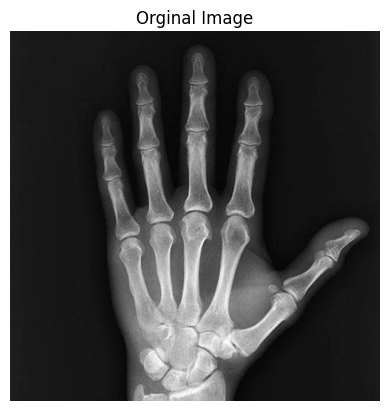

In [13]:
img = image.open("Images/hand_xray.jpg").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Orginal Image")
plt.axis("off")

plt.show()

a) Compute frequency of each intensity level 

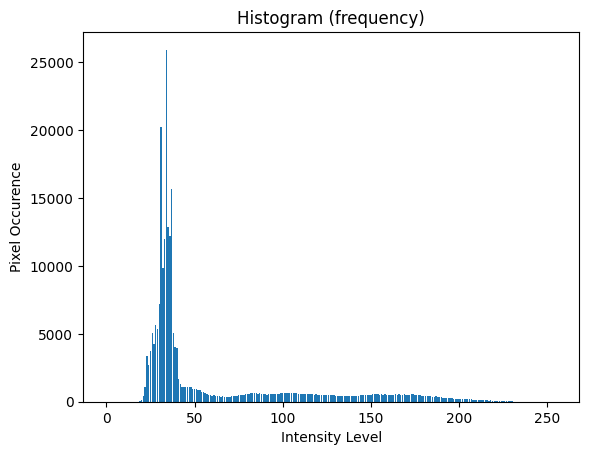

In [14]:
hist = np.zeros(256, dtype=int)

pixels = img_array.flatten()

for i in pixels:
    hist[i] += 1

plt.bar(range(256), hist)
plt.title("Histogram (frequency)")
plt.xlabel("Intensity Level")
plt.ylabel("Pixel Occurence")
plt.show()

b)	Calculate probability density function (PDF) 

In [15]:
total_pixels = img_array.size
pdf = np.zeros(256, dtype=float)

for i in range(256):
    pdf[i] = hist[i] / total_pixels

c)	Compute cumulative distribution function (CDF) 

In [16]:
cdf = np.zeros(256, dtype=float)

cdf[0] = pdf[0]

for i in range(1, 256):
    cdf[i] = cdf[i - 1] + pdf[i]

d)	Map old pixel values to new values

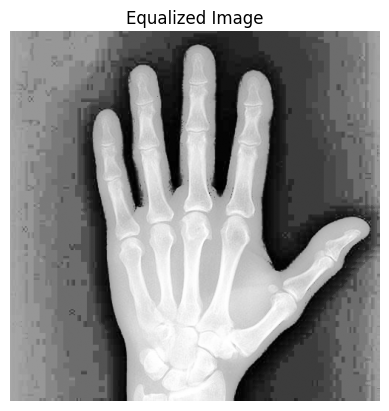

In [17]:
new_levels = np.round(255 * cdf)

equalized_img = np.zeros_like(img_array)
H, W = img_array.shape

for i in range(H):
    for k in range(W):
        equalized_img[i, k] = new_levels[img_array[i, k]]

plt.imshow(equalized_img, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

plt.show()

Histogram after equalization

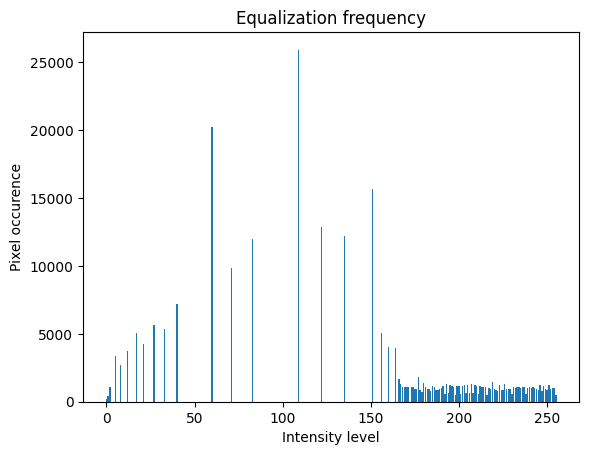

In [18]:
hist = np.zeros(256, dtype=int)

pixels = equalized_img.flatten()

for i in pixels:
    hist[i] += 1

plt.bar(range(256), hist)
plt.title("Equalization frequency")
plt.xlabel("Intensity level")
plt.ylabel("Pixel occurence")
plt.show()